In [1]:
print("Hello world")

Hello world


In [2]:
# handle missing values
import pandas as pd
import numpy as np
data = {
    "colors":['red','green','blue','orange','green','blue',np.nan]
}
df = pd.DataFrame(data)
# print(df)

# handle null values
df.dropna(inplace=True)
print(df)

   colors
0     red
1   green
2    blue
3  orange
4   green
5    blue


In [3]:
# label encoding
from sklearn.preprocessing import LabelEncoder

# method 1
le = LabelEncoder()
df['colors_encoder1'] = le.fit_transform(df['colors'])

# method 2
df['colors_encoder2'] = LabelEncoder().fit_transform(df['colors'])
# print(df)

# method 3
import sklearn
df['colors_encoder3'] = sklearn.preprocessing.LabelEncoder().fit_transform(df['colors'])
print(df)

   colors  colors_encoder1  colors_encoder2  colors_encoder3
0     red                3                3                3
1   green                1                1                1
2    blue                0                0                0
3  orange                2                2                2
4   green                1                1                1
5    blue                0                0                0


In [18]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
print(df)

# drop cols of label encoding
if 'colors_encoder' in df.keys():
  df.drop(df[['colors_encoder','colors_encoder1','colors_encoder2','colors_encoder3']],axis=1,inplace=True)

print(df)

# one hot encoding (by the help of sklearn)

# #one hot encoding
# import pandas as pd
# data = {
# 'colors':['red','blue','green','red','blue']
# }

# df = pd.DataFrame(data)
# print("original data")
# print(df)

# # one hot encoding
# encoded_df = pd.get_dummies(df,columns=['colors'])

# print("after one hot encoding")
# print(encoded_df)

encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['colors']])
print(encoded.toarray())

# one hot encoding (by the help of pandas)
df_encoder = pd.get_dummies(df,columns=['colors'])
print(df_encoder)

  colors
0    red
1   blue
2  green
3    red
4   blue
  colors
0    red
1   blue
2  green
3    red
4   blue
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
   colors_blue  colors_green  colors_red
0        False         False        True
1         True         False       False
2        False          True       False
3        False         False        True
4         True         False       False


In [19]:
# combination of handle missing value | label encoding | onehot encoding
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

data = {
    "age":[10,20,np.nan,26,30],
    "gender":['male','female','others','male',np.nan],
    "name":['dheeraj','kavi','sapu','yash','hello']
}

df = pd.DataFrame(data)

# handle missing values
df['age'] = df['age'].fillna(df['age'].mean())
df.dropna(subset=['gender'],inplace=True)
print(df)

# label encoding
le = LabelEncoder()
df['gender1'] = le.fit_transform(df['gender'])
print(df)

# one hot encoding
oe = OneHotEncoder()
oe_e = oe.fit_transform(df[['gender']]).toarray()
print(oe_e)

    age  gender     name
0  10.0    male  dheeraj
1  20.0  female     kavi
2  21.5  others     sapu
3  26.0    male     yash
    age  gender     name  gender1
0  10.0    male  dheeraj        1
1  20.0  female     kavi        0
2  21.5  others     sapu        2
3  26.0    male     yash        1
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
   experience  salary
0   -1.183216    1000
1   -0.507093    1500
2    0.169031    2000
3    1.521278    3000
0   -1.183216
1   -0.507093
2    0.169031
3    1.521278
Name: experience, dtype: float64
0    1000
1    1500
2    2000
3    3000
Name: salary, dtype: int64


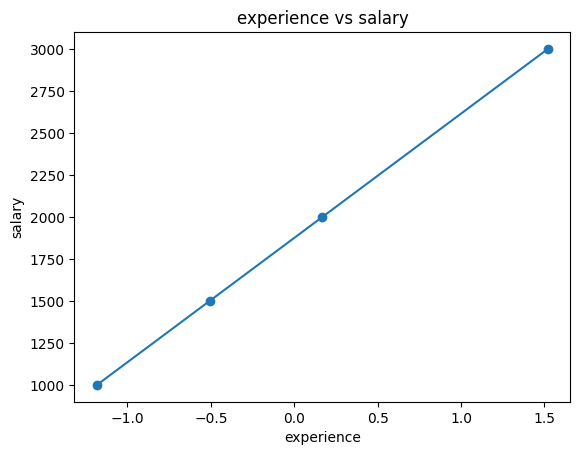

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = {
    "experience":[300,600,900,1500],
    "salary":[1000,1500,2000,3000]
}
# data frame
df = pd.DataFrame(data)
print(df)

# standard scaler
scaler = StandardScaler()
df['experience'] = scaler.fit_transform(df[['experience']]) # 2d
print(df)

# split data exp-> x | sal -> y
X = df['experience'] # capital X
y = df['salary']

print(X)
print(y)

# graph plot
plt.plot(X,y, marker='o') # using plt.plot with markers for better representation
plt.xlabel('experience')
plt.ylabel('salary')
plt.title('experience vs salary')

plt.show()

In [21]:
# data split training testing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = "https://raw.githubusercontent.com/rajendra0968jangid/Ds-Arya/main/extended_salary_data.csv"

df = pd.read_csv(data)
# print(df)

# split data
X = df[['experience']] # capital X -> 2d
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("x train: ",x_train )
print("x test: ",x_test)
print("y train: ", y_train)
print("y test: ", y_test)


x train:       experience
55        17100
22         7200
76        23400
44        13800
72        22200
..          ...
71        21900
14         4800
92        28200
51        15900
102       31200

[83 rows x 1 columns]
x test:      experience
30        9600
65       20100
64       19800
53       16500
45       14100
93       28500
91       27900
47       14700
10        3600
0          300
18        6000
31        9900
88       27000
95       29100
77       23700
4         1800
80       24600
33       10500
12        4200
26        8400
98       30000
y train:  55     29000
22     12500
76     39500
44     23500
72     37500
       ...  
71     37000
14      8500
92     47500
51     27000
102    52500
Name: salary, Length: 83, dtype: int64
y test:  30    16500
65    34000
64    33500
53    28000
45    24000
93    48000
91    47000
47    25000
10     6500
0      1000
18    10500
31    17000
88    45500
95    49000
77    40000
4      3500
80    41500
33    18000
12     7500
26    1

In [24]:
# simple linear reg | prediction
from sklearn.linear_model import LinearRegression

# model fit
model = LinearRegression()
model.fit(x_train,y_train) # 2d

# input from user
user = int(input("Enter your Experience: "))
# model prediction

new_data = {
    "experience":[user]
}

df1 = pd.DataFrame(new_data)
print(df1)
pred_data = model.predict(df1)
print(pred_data[0])

Enter your Experience: 4
   experience
0           4
506.66666666668124
